In [549]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
from sklearn.decomposition import PCA

In [550]:
df= pd.read_csv(r'dataset\realKnownCause\realKnownCause\nyc_taxi.csv')

In [551]:
df.head()

,timestamp,value
0,2014-07-01 00:00:00,10844
1,2014-07-01 00:30:00,8127
2,2014-07-01 01:00:00,6210
3,2014-07-01 01:30:00,4656
4,2014-07-01 02:00:00,3820


In [552]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10320 entries, 0 to 10319
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   timestamp  10320 non-null  object
 1   value      10320 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 161.4+ KB


In [553]:
df.set_index('timestamp', inplace= True)

In [554]:
df.index= pd.to_datetime(df.index, format='mixed')

In [555]:
df.sort_index(inplace=True)

In [556]:
df.isnull().sum()

value    0
dtype: int64

In [557]:
df.value.resample('ME').mean()

timestamp
2014-07-31    14994.084677
2014-08-31    14580.438844
2014-09-30    15623.374306
2014-10-31    16086.851478
2014-11-30    15492.125000
2014-12-31    14813.428763
2015-01-31    14399.790995
Freq: ME, Name: value, dtype: float64

In [558]:
hourly= df.resample('h').mean()
daily= df.resample('D').mean()
monthly= df.resample('ME').mean()

In [559]:
hourly= hourly.asfreq('h')
daily= daily.asfreq('D')
monthly= monthly.asfreq('ME')

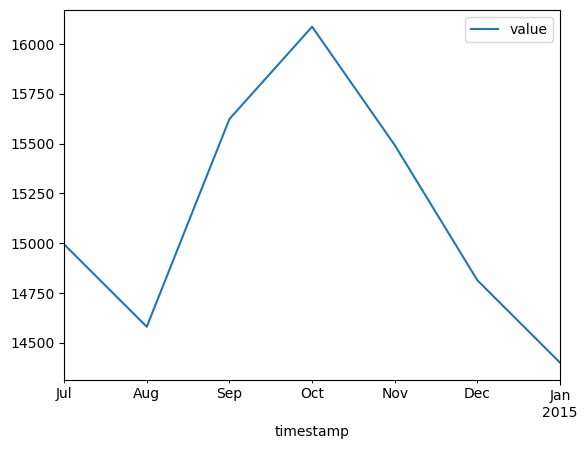

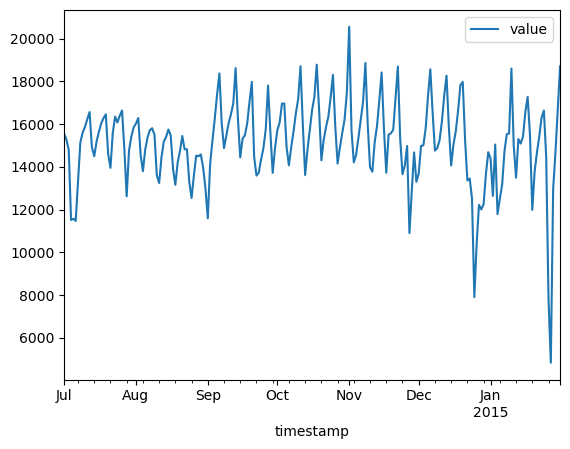

In [560]:
monthly.plot()
daily.plot()


plt.show()

In [561]:
def feature_engineering(data, frequency=str):
  data['day']= data.index.day
  data['month']= data.index.month
  data['year']= data.index.year
  data['dayofyear']= data.index.dayofyear

   

  if frequency== 'daily':
    lags= [1,2,3,7,14,30]
    window= [3,7,14,30]
  elif frequency== 'hourly':
    lags= [1,2,3,5,12,24]
    window=[3,6,12,24]
  elif frequency == 'monthly':
    lags = [1,2,3,6,12]
    window= [3,6,12]
  else:
    print('Enter either daily,hourly or monthly')

  # Adding time stamped lags
  for lag in lags:
    data[f'lag_{lag}']= data['value'].shift(lag)

  # Adding rolling window 
  for i in window:
    data[f'{i}_window_mean']= data['value'].rolling(window=i).mean()
    data[f'{i}_window_std']= data['value'].rolling(window=i).std()
    data[f'{i}_window_max']= data['value'].rolling(window=i).max()
  return data

In [562]:
hourly= feature_engineering(hourly,'hourly')

In [563]:
hourly.dropna(inplace=True)

In [564]:
hourly.head()

,value,day,month,year,dayofyear,lag_1,lag_2,lag_3,lag_5,lag_12,...,3_window_max,6_window_mean,6_window_std,6_window_max,12_window_mean,12_window_std,12_window_max,24_window_mean,24_window_std,24_window_max
timestamp,,,,,,,,,,,,,,,,,,,,,
2014-07-02 00:00:00,11657.5,2,7,2014,183,18107.5,22525.5,23920.0,25865.5,18897.0,...,22525.5,20618.416667,5093.220164,25865.5,20068.833333,4091.858387,25865.5,15631.479167,7474.667995,25865.5
2014-07-02 01:00:00,6744.0,2,7,2014,183,11657.5,18107.5,22525.5,21634.5,18818.5,...,18107.5,17431.500000,6837.154167,23920.0,19062.625000,5624.740342,25865.5,15686.104167,7401.327475,25865.5
2014-07-02 02:00:00,4227.0,2,7,2014,183,6744.0,11657.5,18107.5,23920.0,20068.5,...,11657.5,14530.250000,8245.283347,23920.0,17742.500000,7046.507630,25865.5,15722.791667,7339.425540,25865.5
2014-07-02 03:00:00,2764.0,2,7,2014,183,4227.0,6744.0,11657.5,22525.5,18962.0,...,6744.0,11004.250000,7944.868349,22525.5,16392.666667,8241.743247,25865.5,15745.604167,7296.344302,25865.5
2014-07-02 04:00:00,2527.5,2,7,2014,183,2764.0,4227.0,6744.0,18107.5,15620.5,...,4227.0,7671.250000,6132.983293,18107.5,15301.583333,9167.882180,25865.5,15759.687500,7269.316939,25865.5


In [565]:
x= hourly.copy()

In [566]:
scale= StandardScaler()

In [567]:
scale.fit(x)

StandardScaler()

In [568]:
x= scale.transform(x)

In [569]:
pca= PCA(n_components=2)
x_pca= pca.fit_transform(x)

In [570]:
hourly['x'], hourly['y']= x_pca[:,0], x_pca[:,1]

In [571]:
model= IsolationForest(
        n_estimators=400,
        max_samples=500,
        n_jobs=-1,
        random_state=42,
        contamination='auto',
        max_features=1
)

In [572]:
model.fit(x)

IsolationForest(max_features=1, max_samples=500, n_estimators=400, n_jobs=-1,
                random_state=42)

In [573]:
predictions= model.predict(hourly_scaled)

In [574]:
score= model.decision_function(hourly_scaled)

In [575]:
hourly['anomaly']= predictions
hourly['score']= score

In [ ]:
hourly['anomaly']= hourly['anomaly'].apply(lambda x : 'anomaly' if x == -1 else 'Normal')

In [577]:
hourly['anomaly'].value_counts()

anomaly
Anomaly    4124
Normal     1012
Name: count, dtype: int64

In [578]:
hourly= hourly[['value','day','month','year','anomaly','score','x','y']]

In [579]:
hourly.sample(5)

,value,day,month,year,anomaly,score,x,y
timestamp,,,,,,,,
2014-12-13 00:00:00,24514.0,13,12,2014,Normal,-0.005564,5.485925,0.429578
2015-01-17 13:00:00,20833.0,17,1,2015,Anomaly,0.020544,1.108704,0.087887
2014-11-28 09:00:00,10363.5,28,11,2014,Normal,-0.054791,-5.693745,-3.425924
2015-01-03 12:00:00,19108.5,3,1,2015,Anomaly,0.011708,-1.579349,-1.453236
2014-09-15 14:00:00,17930.5,15,9,2014,Anomaly,0.041792,0.233913,-2.290285


<Axes: xlabel='x', ylabel='y'>

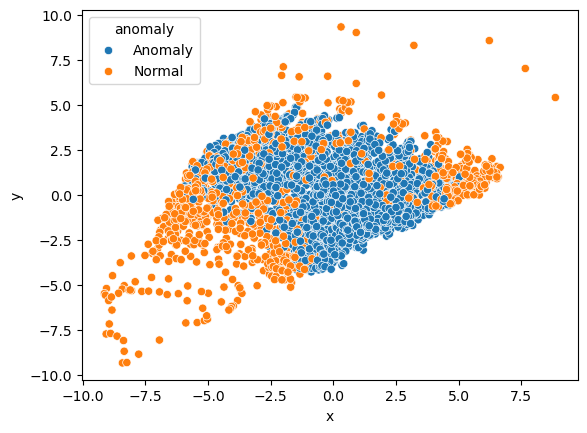

In [580]:
sns.scatterplot(data=hourly, x='x', y='y', hue='anomaly')

<Axes: xlabel='value', ylabel='Count'>

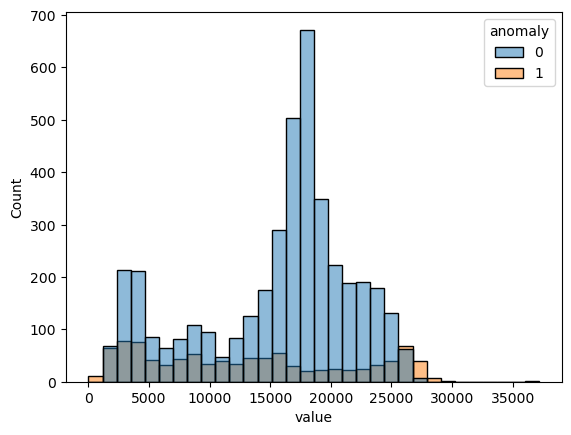

In [548]:
sns.histplot(data=hourly, x='value', hue='anomaly')